<a href="https://colab.research.google.com/github/asrorakromov/Codewars/blob/main/classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sklearn
import torch
import matplotlib

In [38]:
import requests
from pathlib import Path

# Download helper functions from Learn Pytorch repo (if it's not already downloaded)
if Path("helper_function.py").is_file():
  print('helper_function.py already exists, skipping download')
else:
  print('Download helper_function.py')
  request  = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py')
  with open('helper_functions.py', 'wb') as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary, accuracy_fn

Download helper_function.py


In [3]:
# Device agnostic code
device = "cuda" if torch.cuda.is_available else 'cpu'
device

'cuda'

In [4]:
# Creating dataset
from sklearn.datasets import make_circles

samples = 3000

X, y = make_circles(
    samples,
    noise = 0.06,
    random_state=42
    )

In [5]:
len(X), len(y)

(3000, 3000)

In [6]:
import pandas as pd
circles = pd.DataFrame({'X1': X[:, 0],
                        'X2': X[:, 1],
                        'label': y})
circles.head()

,X1,X2,label
0,0.165204,0.727119,1
1,0.211809,-0.981380,0
2,0.270908,0.753869,1
3,0.473709,0.867128,0
4,-0.409740,-0.705089,1


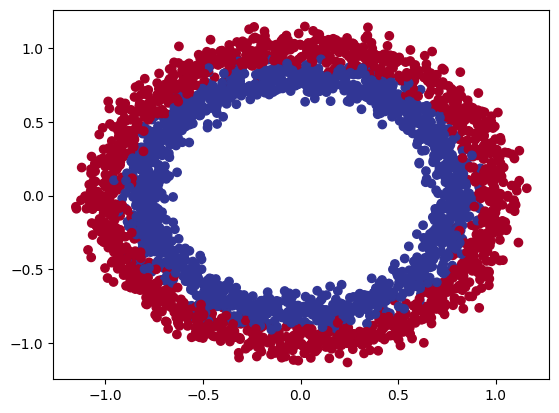

In [7]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu
            );

In [8]:
X.shape, y.shape

((3000, 2), (3000,))

In [9]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [10]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.1652,  0.7271],
         [ 0.2118, -0.9814],
         [ 0.2709,  0.7539],
         [ 0.4737,  0.8671],
         [-0.4097, -0.7051]]),
 tensor([1., 0., 1., 0., 1.]))

In [11]:
type(X), type(y)

(torch.Tensor, torch.Tensor)

In [12]:
# Splitting data into train, test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

In [13]:
len(X_train), len(X_test), len(y_train), len(y_test)

(2400, 600, 2400, 600)

In [24]:
# Model
from torch import nn

class ClassificationModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=10)
    self.layer_4 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_4(self.relu(self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))))

model = ClassificationModel().to(device)
model


ClassificationModel(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=10, bias=True)
  (layer_4): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [25]:
# Loss function and Optimizer
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.1)

In [26]:
# Logits -> Prediction labels
model.eval()
with torch.inference_mode():
  y_logits = model(X_test.to(device))[:5]

y_pred_probs = torch.sigmoid(y_logits)

y_preds = torch.round(y_pred_probs)
y_preds

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], device='cuda:0')

In [37]:
# Training
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 300

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model.train()

  y_logits = model(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model.eval()
  with torch.inference_mode():
    test_logits = model(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_preds)

    if epoch % 50 == 0:
      print(f'Epoch: {epoch} | Loss: {loss:.3f} | Acc: {acc:.2f}% | Test loss: {test_loss:.3f} | Test acc: {test_acc:.2f}%')

Epoch: 0 | Loss: 0.116 | Acc: 95.38% | Test loss: 0.156 | Test acc: 93.33%
Epoch: 50 | Loss: 0.173 | Acc: 93.04% | Test loss: 0.228 | Test acc: 90.50%
Epoch: 100 | Loss: 0.112 | Acc: 95.79% | Test loss: 0.149 | Test acc: 93.83%
Epoch: 150 | Loss: 0.112 | Acc: 95.83% | Test loss: 0.149 | Test acc: 93.83%
Epoch: 200 | Loss: 0.112 | Acc: 95.67% | Test loss: 0.149 | Test acc: 93.67%
Epoch: 250 | Loss: 0.112 | Acc: 95.54% | Test loss: 0.150 | Test acc: 93.83%


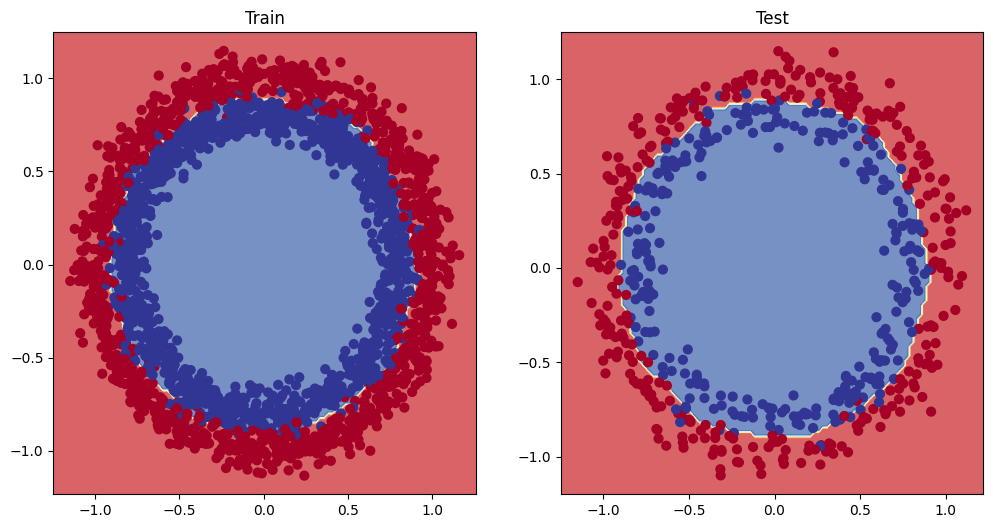

In [39]:
# Making prediction with model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Train')
plot_decision_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title('Test')
plot_decision_boundary(model, X_test, y_test)